# From a business risk to a compute hedge

**The decision:** what price protection should a lender, equipment owner, operator, or compute buyer ask for?

An **input** is a number or assumption we supply; an **output** is a result calculated from those inputs. An **exposure** is something in the business whose dollar outcome changes when prices or quantities change.

A **hedge** is a contract intended to offset a particular business risk. Here it pays cash when a reference rental price moves against its buyer. It does not supply GPUs. We will follow four people from their business problem to the arithmetic behind their proposed protection.

Sections 1–6 form the main lesson. You can work through one person’s scenario at a time; the source walkthrough is optional. No finance background is required. Outputs are saved so you can read without running Python. To experiment, edit the inputs and run the cells again. Prose describes the original inputs.

Adapted from *Liquid Compute Trading Tools v1*, 1 October 2026, pp. 1–2, and *Liquid Compute Trading Tools Math*, `Converter` sheet. The main stories use independent hypothetical inputs; the appendix reproduces the supplied examples. Neither document states the price of buying the protection or supplies a complete contract ready to trade.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

## 1. The vocabulary, attached to a payment

A **GPU** (graphics processing unit) is a processor used for computing work. **Capacity** means the computing service available to use or rent. **USD** means US dollars. One **GPU-hour** means using one GPU for one hour. Ten GPUs for three hours is 30 GPU-hours. A rate of USD 2 per GPU-hour therefore produces a USD 60 bill.

The **reference index** is the agreed published price used to calculate the hedge. Your supplier's actual price can differ. The **strike** is the rate where a payout begins. **Notional** is the number of GPU-hours multiplied by the payout per hour; it is not the price you pay for protection.

An **option** is the protection contract being purchased here. Its **payoff**, or **payout**, is the cash it pays under its formula before subtracting the purchase price. The **settlement price** is the final reference price inserted into that formula; it may be an average over an agreed period.

A **put** pays when the agreed settlement price is below the strike. A **call** pays when it is above. **Cash settlement** means the seller of the option pays money rather than delivering capacity. The **premium** is the price paid to buy the option, whether or not it eventually pays out. These option concepts are explained by the [Options Industry Council's call](https://www.optionseducation.org/strategies/all-strategies/long-call) and [put](https://www.optionseducation.org/strategies/all-strategies/long-put) references; our compute contracts are hypothetical adaptations.

For a put with a USD 2 strike and a USD 1.50 settlement, each covered hour pays USD 0.50. Multiply by 1,000 hours to get USD 500. `max(..., 0)` means “use the positive difference, otherwise pay zero.” A call reverses the subtraction.

In the next cell, `strike = 2.00` is the payout threshold in USD/GPU-hour, `settlement = 1.50` is a hypothetical final index price in the same units, and `covered_hours = 1_000` is the option's notional in GPU-hours. These are scenario inputs, not observed prices. `kind` tells the calculator whether to use the call or put formula. A **scenario** is one possible outcome we choose to examine; it is not a forecast.

In [2]:
from IPython.display import display

from liquid_compute.education import plot_finance_series, show_finance_table
from liquid_compute.hedge_converter import (
    buyer_hedge_terms,
    lender_hedge_terms,
    lessor_hedge_terms,
    operator_hedge_terms,
)
from liquid_compute.options import european_option_payoff_usd

strike = 2.00
settlement = 1.50
covered_hours = 1_000
put_payment = max(strike - settlement, 0) * covered_hours
call_payment = max(settlement - strike, 0) * covered_hours
print(f"Put pays USD {put_payment:,.0f}; call pays USD {call_payment:,.0f}.")
payoff = european_option_payoff_usd  # The existing reusable payoff calculator.
print(
    f"Calculator put payout: USD {payoff(kind='put', settlement_price_usd_per_gpu_hour=settlement, strike_usd_per_gpu_hour=strike, covered_gpu_hours=covered_hours):,.0f}"
)

Put pays USD 500; call pays USD 0.
Calculator put payout: USD 500


The put pays USD 500 because prices fell below its strike; the call pays zero. Neither result subtracts a premium. Next we work backward: which strike and quantity would address each person's problem?

## 2. Maya, the lender: recover the loan principal

**What Maya is worried about:** “I lent money to a business that prepaid for computing time. If that business doesn't repay me, I may have to find new customers for its unused hours. Those customers might pay so little that, after paying the agent who finds them, I cannot get my loan back.”

**What she wants to protect:** Her USD 750,000 loan. A lower rental price is acceptable as long as the money left after fees still repays that amount. She does not need to recover the borrower's entire USD 1 million purchase price.

**How the hedge helps:** It pays cash when the agreed reference rental price falls below the level needed to repay her loan. It does not stop the borrower from failing to repay or guarantee that she can find customers for every remaining hour. The example below assumes all hours are still usable and can be transferred.

Maya is a **lender**: she provides money that a **borrower** must repay. Her borrower is a **capacity reseller**, which buys access to compute and sells that access to customers without owning the GPUs. **Prepaid** means paid before the computing service is used. **Principal** is the amount borrowed, excluding **interest**, the charge for borrowing money.

The reseller prepays **USD 1 million at USD 2.50 per GPU-hour**, buying access to **400,000 GPU-hours**. Maya's **advance rate** is 75%: she lends USD 750,000, and the borrower supplies USD 250,000. Loan **maturity** is when repayment is due, here at month 6. **Month 0** means today; month 6 means six months from today.

**In this scenario, the borrower defaults before using any capacity.** Default means failing to repay as agreed. All 400,000 hours are still unused, unexpired, and available for future service. They are not being consumed while Maya looks for customers in this simplified example. Actual capacity can have delivery dates and expire; unused hours are not automatically transferable or indefinitely available.

Assume Maya has enforceable rights to transfer that remaining capacity to replacement customers: to **re-let** it. One customer could take the whole remaining contract, or several could take portions if the contracts permit it. We assume she places every hour at the modeled rate and collects the replacement customers' payment at month 6. Maya does not own the GPUs. These are assumed rights over capacity, not hardware **collateral**, meaning equipment a lender could claim to support repayment.

Her concern is: **“If the borrower fails to repay and I have to re-let these hours, will the money I collect after fees cover my USD 750,000 loan?”** A lower replacement rental price reduces recovery, but the price can fall below the original USD 2.50 without causing a loss on her loan.

A **remarketing agent** finds the replacement customers and keeps **10% of gross rental receipts**. **Gross** means before the fee; **net** means after it. Maya's **recovery** is those net receipts. A **shortfall** is the positive amount still missing to repay principal. Assume no interest is due, the replacement rental rate equals the index, and the option pays at month 6 using the final month's average index.

Maya's inputs for the calculation:

| Input name in Python | Value and unit | Meaning in this story |
|---|---|---|
| `contract_usd_per_gpu_hour` | 2.50 USD/GPU-hour | Price used to buy the prepaid capacity; converts the purchase dollars into hours. |
| `prepaid_usd` | 1,000,000 USD | Total capacity purchase paid in advance, not the loan amount. |
| `advance_fraction` | 0.75 = 75% | Share of the purchase Maya lends; the borrower supplies the other 25%. |
| `remarketing_fee_fraction` | 0.10 = 10% | Share of replacement rental receipts paid to the agent, not a fee on loan principal. |
| `index` | 1.50, the calculated strike, 2.50, or 3.00 USD/GPU-hour | Alternative final reference prices used to compare outcomes. |

A **fraction** expresses a share as a decimal: 75% becomes `0.75`, and `1 - 0.10` leaves 90%. The six-month maturity determines timing; it does not change this principal-only sizing formula.

### Why 400,000 physical hours become a 360,000-hour notional

First find the hours purchased: **USD 1,000,000 ÷ USD 2.50 per GPU-hour = 400,000 GPU-hours**. These are the physical capacity rights available to re-let.

The agent receives **10% of rental revenue, not 10% of the hours**. All 400,000 hours are re-let. Maya keeps 90% of the money, so a USD 1 fall in the rental rate has three effects:

| Effect of a USD 1/GPU-hour price fall | Change in cash |
|---|---:|
| Gross receipts fall: 400,000 hours × USD 1/hour | USD 400,000 less |
| The agent's fee falls: 10% × USD 400,000 | USD 40,000 less to pay |
| Maya's net recovery falls: 400,000 − 40,000 | **USD 360,000 less** |

We therefore want the put to pay **USD 360,000 for each USD 1/GPU-hour decline below its strike**. That makes its notional **400,000 × 90% = 360,000 GPU-hours**.

Think of an example share option covering 100 shares: multiply its per-share payout by 100. Here we multiply the per-GPU-hour payout by 360,000. That is the agreed payout quantity for this hypothetical hedge, not a claim that compute options have a standard contract size.

**The 360,000 is a cash-payout multiplier. It does not mean that 40,000 hours are unprotected or that the agent took those hours.** The fee is already accounted for in this sizing; we do not deduct another 10% from the option payout.

In code, the same reasoning becomes:

`notional = (prepaid_usd / contract_usd_per_gpu_hour) × (1 - remarketing_fee_fraction)`


### Why Maya's protection begins below USD 2.50

The **original contract rate**, USD 2.50/GPU-hour, tells us how many hours the prepayment bought. The **strike** answers a different question: at what replacement rental rate do receipts after fees just cover Maya's loan?

Maya lent **75% × USD 1,000,000 = USD 750,000**. If all hours can still be re-let at USD 2.50, gross receipts are USD 1,000,000. After the USD 100,000 agent fee, USD 900,000 remains available to repay a USD 750,000 loan. That leaves a USD 150,000 cushion before Maya suffers a principal shortfall.

Find the rate that uses up that cushion by solving:

**400,000 hours × rental rate × 90% = USD 750,000.**

Divide the loan by the fee-adjusted notional:

**Strike = USD 750,000 ÷ 360,000 GPU-hours = USD 2.083333… per GPU-hour.**

A fall from USD 2.50 to USD 2.20 therefore does not create a principal loss for Maya: recovery is still USD 792,000 after fees. At USD 2.083333…, recovery exactly covers her loan. Below that rate, the put starts paying. It protects her loan-recovery threshold, not every decline from the reseller's original purchase price.

The strike and notional must be used together. Algebraically, `strike = advance × contract_rate / (1 - fee)`. Keep full precision when calculating the payout.


In [3]:
lender_inputs = dict(
    contract_usd_per_gpu_hour=2.50,
    prepaid_usd=1_000_000,
    advance_fraction=0.75,
    remarketing_fee_fraction=0.10,
)
prepaid_hours = (
    lender_inputs["prepaid_usd"] / lender_inputs["contract_usd_per_gpu_hour"]
)
loan = lender_inputs["prepaid_usd"] * lender_inputs["advance_fraction"]
hedge_notional_gpu_hours = prepaid_hours * (
    1 - lender_inputs["remarketing_fee_fraction"]
)
lender_strike = loan / hedge_notional_gpu_hours
print(f"Purchased: {prepaid_hours:,.0f} GPU-hours; loan: USD {loan:,.0f}")
print(
    f"Notional: {hedge_notional_gpu_hours:,.0f} GPU-hours; strike: USD {lender_strike:.6f}/GPU-hour"
)
lender = lender_hedge_terms(**lender_inputs)

rows = []
for index in [1.50, lender.strike_usd_per_gpu_hour, 2.50, 3.00]:
    gross_relet_receipts = index * prepaid_hours
    agent_fee = gross_relet_receipts * lender_inputs["remarketing_fee_fraction"]
    recovery = gross_relet_receipts - agent_fee
    shortfall = max(loan - recovery, 0)
    payment = payoff(
        kind=lender.kind,
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=lender.strike_usd_per_gpu_hour,
        covered_gpu_hours=lender.notional_gpu_hours,
    )
    rows.append([index, recovery, shortfall, payment, min(recovery, loan) + payment])
show_finance_table(
    [
        "Index USD/GPU-hour",
        "Net re-let USD",
        "Principal shortfall USD",
        "Put pays USD",
        "Lender receives USD*",
    ],
    rows,
)

Purchased: 400,000 GPU-hours; loan: USD 750,000
Notional: 360,000 GPU-hours; strike: USD 2.083333/GPU-hour


| Index USD/GPU-hour | Net re-let USD | Principal shortfall USD | Put pays USD | Lender receives USD* |
| --- | --- | --- | --- | --- |
| 1.50 | 540,000.00 | 210,000.00 | 210,000.00 | 750,000.00 |
| 2.08 | 750,000.00 | 0.00 | 0.00 | 750,000.00 |
| 2.50 | 900,000.00 | 0.00 | 0.00 | 750,000.00 |
| 3.00 | 1,080,000.00 | 0.00 | 0.00 | 750,000.00 |

At **USD 1.50/GPU-hour**, the replacement customers pay **400,000 × 1.50 = USD 600,000**. The agent receives **10% × 600,000 = USD 60,000**, leaving **USD 540,000** for Maya. Her USD 750,000 loan is therefore **USD 210,000 short**.

The put fills that gap: **(2.083333… − 1.50) × 360,000 = USD 210,000**. Maya combines USD 540,000 of net rental recovery with USD 210,000 from the option to recover USD 750,000, before paying any option premium. No second remarketing fee is taken from the put payout.

At the strike, rental recovery alone exactly repays principal. At **USD 2.50**, it produces USD 900,000 after fees, already more than the loan, so the put pays zero. The last table column assumes Maya keeps only principal from re-letting; excess recovery belongs to the borrower.

The model separates **the reason Maya may need to re-let** (borrower default) from **what makes the put pay** (a low settlement index). An ordinary index put can pay even when the borrower repays normally. It cannot fill every default loss: the borrower could fail to repay while the index stays above the strike.

If hours have been consumed, expired, cannot be transferred, or cannot find customers, Maya has less capacity available for recovery. Her remaining loan balance, usable hours, and hedge quantity would then need to be reassessed together. The USD 750,000 result relies on all 400,000 hours being placed at the index price, the stated fee, and an option seller that pays. Interest and the option premium require additional cash.


## 3. Leon, the equipment owner: earn a residual target

**What Leon is worried about:** “I paid USD 10,000 for each GPU. By the end of the first rental agreement, I expect to have recovered USD 4,000 per GPU after running costs. I still need another USD 6,000 per GPU to recover what I originally spent. If the next customers pay much lower rental rates, I may not earn back that remaining investment over the next year.”

**What he wants to protect:** The remaining USD 600,000 of purchase cost he expects still to have tied up in 100 GPUs: USD 6,000 per GPU. He plans to recover it through the next year's rentals after running costs. That USD 6,000 is money needed to earn back his original investment, not an extra USD 6,000 of profit.

**How the hedge helps:** It pays cash if the reference rental price at the end of the current lease is too low to support that target under his assumptions. It does not promise a hardware sale price, future customers, or a particular rental rate throughout the following year. Those differences are why this is only an estimate of protection for his future rental income.

Leon owns **100 GPUs** whose **lease**, the agreement letting someone use his equipment for a period, ends at month 24. A **lessor** is the owner renting equipment to another party.

**Where the USD 6,000 comes from.** To give his target a concrete business reason, add these hypothetical assumptions about the purchase and first lease:

| Purchase-cost recovery | Per GPU | All 100 GPUs |
|---|---:|---:|
| Original equipment purchase cost | USD 10,000 | USD 1,000,000 |
| Cash expected from the first lease after its operating costs | USD 4,000 | USD 400,000 |
| Purchase cost still to recover: 10,000 − 4,000 | **USD 6,000** | **USD 600,000** |

The USD 4,000 is cash left **after** paying the first lease's running costs, not its total rental bill. Both the USD 10,000 purchase cost and the USD 4,000 first-lease recovery are new teaching assumptions, not figures from the supplied documents. If that first lease earns less than expected, the remaining amount Leon needs to recover will be larger.

He asks: **“What rental rate over the following 12 months would leave me with that last USD 6,000 per GPU after paying the next year's running costs?”** Recovering it would bring cumulative rental cash after operating costs to the original purchase cost, before financing costs, taxes, and the option premium. It does not yet provide an additional return for the time and risk of his investment. He would still own the GPUs; no equipment sale is included in these totals.

The **book residual** is the value assumed to remain in his accounting records at lease end. Separately, assume it is also USD 6,000 per GPU in this story, so it matches his remaining purchase-cost recovery target. The subtraction above explains his cash target; it is **not a rule for calculating accounting book value**. Neither figure guarantees a sale price or future rental income.

Assume **75% utilization** (the share of available hours billed), **730 hours per GPU-month**, and **USD 0.50 operating cost per billed GPU-hour**. The 730 convention comes from the workbook; real calendar months vary. **Billed hours** are hours charged to customers; **available hours** include both billed and idle capacity. **Revenue** is income earned from customers before subtracting costs. **Operating costs** are the costs of running the service, such as power and operations. Costs here scale only with billed hours.

Leon's inputs in the next cell:

| Input name in Python | Value and unit | Meaning in this story |
|---|---|---|
| `gpu_count` | 100 GPUs | Number of processors Leon owns and can re-let. |
| `residual_usd_per_gpu` | 6,000 USD/GPU | Remaining purchase cost to earn back per GPU after the next rental period's operating costs; also the assumed book residual here. |
| `relet_months` | 12 months | Length of the new rental period after the old lease ends. |
| `utilization_fraction` | 0.75 = 75% | Share of available hours assumed to earn rental revenue. |
| `hours_per_gpu_month` | 730 hours/GPU-month | Simplified monthly capacity per GPU, before applying utilization. |
| `opex_usd_per_billed_gpu_hour` | 0.50 USD/billed GPU-hour | Operating expense, abbreviated **opex**, for each hour charged to a customer. |
| `relet_rate` | 1.20 USD/GPU-hour | Rental-price scenario, assumed equal to the option's settlement index. |

Lease end at month 24 sets the observation date. The 12-month re-let term determines how many later hours can earn the residual target. These are different inputs.

Divide residual dollars by billed hours per GPU to find the required net earnings per hour. Add operating cost to get the required gross rental rate. Multiply billed hours per GPU by GPU count to size the put.

In [4]:
lessor_inputs = dict(
    gpu_count=100,
    residual_usd_per_gpu=6_000,
    relet_months=12,
    utilization_fraction=0.75,
    opex_usd_per_billed_gpu_hour=0.50,
    hours_per_gpu_month=730,
)
hours_each = (
    lessor_inputs["utilization_fraction"]
    * lessor_inputs["hours_per_gpu_month"]
    * lessor_inputs["relet_months"]
)
lessor_strike = (
    lessor_inputs["residual_usd_per_gpu"] / hours_each
    + lessor_inputs["opex_usd_per_billed_gpu_hour"]
)
lessor_hours = lessor_inputs["gpu_count"] * hours_each
print(f"Billed hours per GPU: {hours_each:,.0f}; total: {lessor_hours:,.0f}")
print(f"Strike: USD {lessor_strike:.6f}/GPU-hour")
lessor = lessor_hedge_terms(**lessor_inputs)
relet_rate = 1.20
earnings = (relet_rate - lessor_inputs["opex_usd_per_billed_gpu_hour"]) * lessor_hours
payment = payoff(
    kind=lessor.kind,
    settlement_price_usd_per_gpu_hour=relet_rate,
    strike_usd_per_gpu_hour=lessor.strike_usd_per_gpu_hour,
    covered_gpu_hours=lessor.notional_gpu_hours,
)
show_finance_table(
    ["Rental earnings after costs USD", "Put pays USD", "Combined USD"],
    [[earnings, payment, earnings + payment]],
)

Billed hours per GPU: 6,570; total: 657,000
Strike: USD 1.413242/GPU-hour


| Rental earnings after costs USD | Put pays USD | Combined USD |
| --- | --- | --- |
| 459,900.00 | 140,100.00 | 600,000.00 |

Each GPU supplies 6,570 billed hours. Leon needs roughly USD 0.913242 net per hour to earn USD 6,000, so the gross strike is roughly USD 1.413242 after adding USD 0.50 costs. At USD 1.20, rental earnings are USD 459,900 and the put adds USD 140,100: USD 600,000 in total before premium.

This is an **undiscounted rental-income target**: future dollars are added without adjusting for how long Leon waits to receive them. **Discounting** would convert future cash to an equivalent value today using a chosen rate. The calculation is not proof the equipment is worth USD 600,000 today or can be sold for that amount. We add no hardware sale proceeds. The document's option settles on the final month of the old lease, while rental income arrives over the next year. The equality between combined receipts and the target requires Leon to lock that whole year's rental rate to the settlement index and achieve the assumed hours and costs. Otherwise, the payoff and later earnings can diverge. Earlier cash is also economically different from later cash.

## 4. Omar, the operator: cover costs after contracts expire

**What Omar is worried about:** “My current customers' contracts will end, but I will still have operating bills and loan payments. If the next customers pay less per hour, I could keep the GPUs busy and still not bring in enough money to cover those payments.”

**What he wants to protect:** Enough cash from the next 12 months of service to cover the modeled costs and loan payments. At his planned number of billed hours, he needs USD 1.80 per hour. The aim is to avoid a cash shortfall caused by lower rental rates, not to guarantee a profit.

**How the hedge helps:** It pays cash when the reference rental price averages below USD 1.80 over the protected period. It does not fill idle GPUs or pay for unexpected cost increases. It also pays at the end of the period in this example, so Omar still needs cash for earlier bills.

Omar is an **operator**, the business running a cluster, or group, of **200 GPUs** to provide compute service. Running the GPUs does not by itself establish ownership. Existing customer contracts end, or **roll off**, at month 12; he needs price protection for the **next 12 months**. At **80% utilization**, he supplies 1,401,600 billed hours. His supplied **break-even rate is USD 1.80 per billed GPU-hour**: at planned volume, revenue at that rate covers operating costs and debt payments. A debt payment is cash owed on borrowing, not necessarily an accounting expense.

Omar's inputs in the next cell:

| Input name in Python | Value and unit | Meaning in this story |
|---|---|---|
| `gpu_count` | 200 GPUs | Capacity Omar operates. |
| `months` | 12 months | Length of the **uncontracted period**, when no existing customer agreement fixes his rental revenue. |
| `utilization_fraction` | 0.80 = 80% | Share of available hours expected to be billed. |
| `breakeven_usd_per_gpu_hour` | 1.80 USD/billed GPU-hour | Revenue needed per billed hour to cover the stated costs and debt payments at planned volume. This is supplied, not derived here. |
| `hours_per_gpu_month` | 730 hours/GPU-month | Monthly hours available from each GPU before utilization. |
| `index` | 1.20, 1.80, or 2.40 USD/GPU-hour | Alternative average reference prices over the protected period. |

The **window** is the period over which reference prices are observed: from the month-12 boundary to the month-24 boundary. **Volume** here means billed GPU-hours. **Cash surplus** is revenue minus the modeled operating costs and debt payments; a negative surplus means a cash deficit. **Debt service** is another name for required loan principal and interest payments.

Unlike Leon, Omar already knows his required hourly rate. Use it directly as the put strike. GPU count × utilization × hours per month × months gives notional. We assume his actual rental price equals the window's index average, with equal billed hours each month.

In [5]:
operator_inputs = dict(
    gpu_count=200,
    months=12,
    utilization_fraction=0.80,
    breakeven_usd_per_gpu_hour=1.80,
    hours_per_gpu_month=730,
)
operator_hours = (
    operator_inputs["gpu_count"]
    * operator_inputs["utilization_fraction"]
    * operator_inputs["hours_per_gpu_month"]
    * operator_inputs["months"]
)
operator_strike = operator_inputs["breakeven_usd_per_gpu_hour"]
print(
    f"Notional: {operator_hours:,.0f} GPU-hours; strike: USD {operator_strike:.2f}/GPU-hour"
)
operator = operator_hedge_terms(**operator_inputs)
rows = []
for index in [1.20, 1.80, 2.40]:
    surplus = (index - operator_strike) * operator_hours
    payment = payoff(
        kind=operator.kind,
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=operator.strike_usd_per_gpu_hour,
        covered_gpu_hours=operator.notional_gpu_hours,
    )
    rows.append([index, surplus, payment, surplus + payment])
show_finance_table(
    [
        "Average USD/GPU-hour",
        "Unhedged cash surplus USD",
        "Put pays USD",
        "Hedged cash surplus USD",
    ],
    rows,
)

Notional: 1,401,600 GPU-hours; strike: USD 1.80/GPU-hour


| Average USD/GPU-hour | Unhedged cash surplus USD | Put pays USD | Hedged cash surplus USD |
| --- | --- | --- | --- |
| 1.20 | -840,960.00 | 840,960.00 | 0.00 |
| 1.80 | 0.00 | 0.00 | 0.00 |
| 2.40 | 840,960.00 | 0.00 | 840,960.00 |

At USD 1.20, Omar is USD 840,960 short of the modeled costs. The put fills that gap. At USD 2.40, he keeps the USD 840,960 operating cash surplus and receives no put payment. All three cases exclude premium.

The put protects the planned rate exposure. It does not bring customers to idle GPUs. If utilization drops, costs per billed hour may rise and the assumed break-even rate must be recalculated. We assume payment at the end of month 24; Omar may still need cash to pay bills before the hedge settles.

## 5. Bea, the buyer: keep a compute purchase within budget

**What Bea is worried about:** “I know how much computing time I will need, but I have not locked in its price. If rental rates rise before or during the period when I need it, the same amount of computing time could cost more than my approved budget.”

**What she wants to protect:** Her planned compute spending of USD 3 per hour, or USD 1,314,000 for 438,000 hours. She wants money to help cover a higher bill while still benefiting if compute becomes cheaper.

**How the hedge helps:** It pays cash when the reference rental price averages above USD 3 over her purchase period. She still has to arrange the actual capacity. Buying the hedge adds a separate cost, and a supplier price above the reference price can still leave her over budget. We calculate both effects below.

Bea is a **compute buyer**, paying to use capacity rather than to own the equipment. She needs **50 reserved GPUs** for **12 months starting at month 6**. Her budget is **USD 3 per GPU-hour**. **Reserved** means set aside for her use under the hypothetical purchase terms. She pays for every reserved hour, even if some go unused, so there is no utilization multiplier. A rising price hurts her, which calls for a call.

Bea's inputs in the next cell:

| Input name in Python | Value and unit | Meaning in this story |
|---|---|---|
| `gpu_count` | 50 GPUs | Number of processors reserved for Bea. |
| `months` | 12 months | Duration of the reservation, starting at month 6. |
| `budget_usd_per_gpu_hour` | 3.00 USD/GPU-hour | Maximum planned compute price before paying for the option; used as its strike. |
| `hours_per_gpu_month` | 730 hours/GPU-month | Hours charged per reserved GPU each month under this example's convention. |
| `premium_per_hour` | 0.20 USD/covered GPU-hour | Invented option purchase price per hour of notional; multiplied by total covered hours once, not charged again each month. |
| `prices` | 2.00, 3.00, 4.00, 5.00 USD/GPU-hour | Alternative settlement averages; each scenario also assumes this is Bea's actual purchase rate. |

Start at month 6 identifies when service begins; duration determines how many hours she buys. A **cap** is an upper limit on a cost. A **floor** is a lower limit on receipts. The examples only achieve their stated cap or floor under the matching-price and quantity assumptions.

The purchase covers 50 × 730 × 12 = 438,000 hours. Set the strike to the budget ceiling. At a USD 4 average price, the call pays USD 1 for every covered hour; subtract that receipt from the compute bill. The table and chart compare no hedge with a call before and after its premium.

Notional: 438,000 GPU-hours; budget: USD 1,314,000


| Index USD/GPU-hour | No hedge USD | Call pays USD | Cost before premium USD | Cost with premium USD |
| --- | --- | --- | --- | --- |
| 2.00 | 876,000.00 | 0.00 | 876,000.00 | 963,600.00 |
| 3.00 | 1,314,000.00 | 0.00 | 1,314,000.00 | 1,401,600.00 |
| 4.00 | 1,752,000.00 | 438,000.00 | 1,314,000.00 | 1,401,600.00 |
| 5.00 | 2,190,000.00 | 876,000.00 | 1,314,000.00 | 1,401,600.00 |

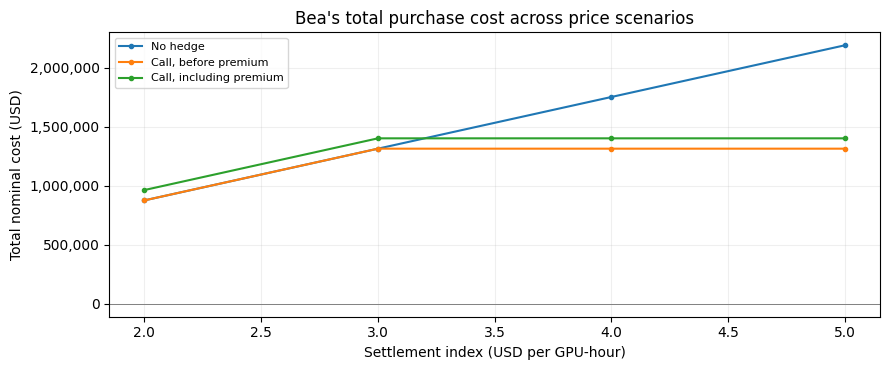

In [6]:
buyer_inputs = dict(
    gpu_count=50, months=12, budget_usd_per_gpu_hour=3.00, hours_per_gpu_month=730
)
buyer_hours = (
    buyer_inputs["gpu_count"]
    * buyer_inputs["hours_per_gpu_month"]
    * buyer_inputs["months"]
)
buyer_strike = buyer_inputs["budget_usd_per_gpu_hour"]
print(
    f"Notional: {buyer_hours:,.0f} GPU-hours; budget: USD {buyer_strike * buyer_hours:,.0f}"
)
buyer = buyer_hedge_terms(**buyer_inputs)
premium_per_hour = 0.20  # Invented teaching quote, not supplied by the documents.
premium = premium_per_hour * buyer_hours
prices = [2.00, 3.00, 4.00, 5.00]
rows = []
for index in prices:
    bill = index * buyer_hours
    payment = payoff(
        kind=buyer.kind,
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=buyer.strike_usd_per_gpu_hour,
        covered_gpu_hours=buyer.notional_gpu_hours,
    )
    rows.append([index, bill, payment, bill - payment, bill - payment + premium])
show_finance_table(
    [
        "Index USD/GPU-hour",
        "No hedge USD",
        "Call pays USD",
        "Cost before premium USD",
        "Cost with premium USD",
    ],
    rows,
)
display(
    plot_finance_series(
        {
            "No hedge": [r[1] for r in rows],
            "Call, before premium": [r[3] for r in rows],
            "Call, including premium": [r[4] for r in rows],
        },
        x_values=prices,
        title="Bea's total purchase cost across price scenarios",
        xlabel="Settlement index (USD per GPU-hour)",
        ylabel="Total nominal cost (USD)",
    )
)

At USD 4, Bea's bill is USD 1,752,000 and the call pays USD 438,000. The remaining USD 1,314,000 equals her original budget. At USD 2, she benefits from cheaper compute and the call pays zero.

Our invented USD 0.20-per-hour premium costs USD 87,600. Including it raises the maximum matched cost to USD 1,401,600, or **USD 3.20 per hour**. The strike alone therefore does not cap total spending at USD 3. For a put, premium similarly reduces the protected net receipts. **Nominal dollars** are the stated amounts paid or received at their respective dates, with no adjustment for timing. We add those amounts here rather than discounting them to today.

Assume premium is paid at month 0, compute bills are paid monthly over the service period, and the call pays at month 18 after the average is known. The final cost comparison does not mean Bea has enough cash for every earlier bill.

### Experiment: the supplier charges more than the index

Keep Bea's original 438,000 hours, USD 3 strike, and USD 87,600 premium. Suppose the index averages USD 4 but her supplier averages USD 4.30. This price difference is called **basis**. The option still uses USD 4.

For this experiment, `experiment_hours` is the fixed quantity of 438,000 GPU-hours; `index` is the USD 4/GPU-hour hedge reference; `supplier_price` is the actual USD 4.30/GPU-hour charge; and `experiment_premium` is the total USD 87,600 option price. **Residual basis cost** means the price difference left unprotected: `(supplier_price - index) × experiment_hours`. These inputs are fixed separately so earlier edits do not change this worked example.

In [7]:
# Fixed experiment: independent of edits to the earlier examples.
experiment_hours = 50 * 730 * 12
index = 4.00
supplier_price = 4.30
experiment_premium = 0.20 * experiment_hours
call_receipt = max(index - 3.00, 0) * experiment_hours
actual_bill = supplier_price * experiment_hours
extra_basis_cost = (supplier_price - index) * experiment_hours
print(f"Actual bill: USD {actual_bill:,.0f}; call receipt: USD {call_receipt:,.0f}")
print(f"Residual basis cost: USD {extra_basis_cost:,.0f}")
print(
    f"Total cost including premium: USD {actual_bill - call_receipt + experiment_premium:,.0f}"
)

Actual bill: USD 1,883,400; call receipt: USD 438,000
Residual basis cost: USD 131,400
Total cost including premium: USD 1,533,000


The supplier bill rises to USD 1,883,400, but the call still pays USD 438,000. The USD 0.30 difference adds USD 131,400 of unprotected cost. Including premium, Bea spends USD 1,533,000, or USD 3.50 per hour. The call offsets the index move, not every change in her invoice.

## 6. Translate the story into a request for a quote

A **request for quote (RFQ)** asks a **dealer**, a business offering to trade the option, what it would charge for specified protection. A **quote** is the proposed price and terms; an **RFQ ticket** is the structured description sent to request that quote. It is not itself a trade. **Expiry** is the end of the option's contractual life; its cash-payment date must also be specified. An **observation** is one recorded index price. **Observation weights** say how much each recorded price contributes to an average; equal weights mean each counts equally. The source's converter provides the starting fields below; actual calendar dates, index methodology, observation weights, payment dates, and legal terms still need agreement.

| Field | What our four people would specify |
|---|---|
| Product | Maya, Leon, Omar: buy a cash-settled put. Bea: buy a cash-settled call. |
| Reference | Exact index series, hardware/service definition, region, and USD/GPU-hour units. The source proposes **LCI H100**, its named index series for H100 GPU rental prices; the exact series and its rules still need confirmation. |
| Strike and notional | Use the unrounded calculated rate and GPU-hours, not the rounded display. |
| Expiry and averaging | Maya: final-month average at month 6. Leon: final-month average at month 24. Omar: average over the 12 months after month 12. Bea: average over the 12 months after month 6. |
| Cash payment | Our examples assume payment at the end of the observation period. An **invoice** is a bill; its issue date may differ from the date money is paid. |
| Premium | Ask for both USD per covered GPU-hour and total USD, plus when it must be paid. |

“From month 6 to month 18” means a 12-month interval between those boundaries, not 13 monthly observations. An **average-price option** first averages the observations and then calculates one payoff. It does not pay a separate option for each month. Neither document defines the exact daily observation or weighting rule.

Before accepting a quote, each person should be able to explain the actual quantity exposed, why the index matches the business price, when cash is needed, and what happens if either the physical supplier or the option seller fails to perform. A cash payment does not guarantee physical capacity. The next lessons are [M3 on basis risk](M3_benchmark_basis_risk.ipynb), [M5 on options](M5_calls_and_puts.ipynb), and [M7 on liquidity](M7_hedge_collateral_liquidity.ipynb).

## Optional appendix: reproduce the two supplied documents

This section uses the source inputs exactly. References such as `B16` mean cells on the workbook's **Converter** sheet. All deal inputs are illustrative according to its `README!B8`. The source labels USD 2.87 as LCI H100 (US) on 30 September 2026 (`B3`); we retain it **only as a supplied, independently unverified comparison value**. It is neither a forecast nor a live quote. It does not determine any strike or notional.

### A. The source lender

Inputs `B8:B12`: USD 2.50 contract rate, USD 10 million prepaid, 80% advance, 10% fee, six-month maturity. Divide prepayment by contract rate (`B14`), multiply prepayment by advance (`B15`), and divide advance × contract rate by the retained 90% (`B16`). Divide strike by the contract rate and by 2.87 to obtain the two comparison percentages (`B17:B18`). Neither is a probability.

Multiply prepaid hours by 90% for notional (`B19`). At a zero index, the put pays strike × notional (`B20`). For `B22:B26`, multiply the USD 1.80 test settlement by the retained hours, subtract recovery from principal if positive, calculate the put payout, and compare them.

In [8]:
source_lender = lender_hedge_terms(
    contract_usd_per_gpu_hour=2.50,
    prepaid_usd=10_000_000,
    advance_fraction=0.80,
    remarketing_fee_fraction=0.10,
)
source_index = 2.87
source_hours = 10_000_000 / 2.50
source_loan = 0.80 * 10_000_000
source_recovery = 1.80 * 0.90 * source_hours
source_shortfall = max(source_loan - source_recovery, 0)
source_payment = payoff(
    kind="put",
    settlement_price_usd_per_gpu_hour=1.80,
    strike_usd_per_gpu_hour=source_lender.strike_usd_per_gpu_hour,
    covered_gpu_hours=source_lender.notional_gpu_hours,
)
show_finance_table(
    ["Workbook cell / output", "Calculated value"],
    [
        ["B14: prepaid GPU-hours", source_hours],
        ["B15: loan USD", source_loan],
        ["B16: strike USD/GPU-hour", f"{source_lender.strike_usd_per_gpu_hour:.12f}"],
        [
            "B17: strike / contract",
            f"{source_lender.strike_usd_per_gpu_hour / 2.50:.6%}",
        ],
        [
            "B18: strike / supplied index",
            f"{source_lender.strike_usd_per_gpu_hour / source_index:.6%}",
        ],
        ["B19: notional GPU-hours", source_lender.notional_gpu_hours],
        [
            "B20: maximum put payout USD",
            source_lender.strike_usd_per_gpu_hour * source_lender.notional_gpu_hours,
        ],
        ["B23: recovery USD", source_recovery],
        ["B24: shortfall USD", source_shortfall],
        ["B25: put pays USD", source_payment],
        ["B26: payout minus shortfall USD", source_payment - source_shortfall],
    ],
)

| Workbook cell / output | Calculated value |
| --- | --- |
| B14: prepaid GPU-hours | 4,000,000.00 |
| B15: loan USD | 8,000,000.00 |
| B16: strike USD/GPU-hour | 2.222222222222 |
| B17: strike / contract | 88.888889% |
| B18: strike / supplied index | 77.429346% |
| B19: notional GPU-hours | 3,600,000.00 |
| B20: maximum put payout USD | 8,000,000.00 |
| B23: recovery USD | 6,480,000.00 |
| B24: shortfall USD | 1,520,000.00 |
| B25: put pays USD | 1,520,000.00 |
| B26: payout minus shortfall USD | 0.00 |

The USD 6.48 million recovery and USD 1.52 million payout together cover the USD 8 million principal. The zero difference holds both below the strike and at/above it, where both shortfall and payout are zero, apart from floating-point rounding. The workbook's note mentions only prices below strike.

The PDF rounds the strike to USD 2.22. Using 2.22 literally would pay USD 1,512,000 at a USD 1.80 settlement, leaving USD 8,000 uncovered. Keep full precision in calculations; any contractual strike rounding changes protection.

### B. The source equipment lessor

Inputs `B30:B35`: 512 GPUs, lease ending in 24 months, USD 8,000 residual per GPU, 12-month re-let term, 70% utilization, and USD 0.40 operating cost per billed hour. Utilization × 730 × 12 gives hours per GPU (`B37`). Divide 8,000 by those hours and add 0.40 for strike (`B38`). Divide by 2.87 for the comparison (`B39`); multiply hours per GPU by 512 for notional (`B40`). Maximum payout at zero index is strike × notional (`B41`).

In [9]:
source_lessor = lessor_hedge_terms(
    gpu_count=512,
    residual_usd_per_gpu=8_000,
    relet_months=12,
    utilization_fraction=0.70,
    opex_usd_per_billed_gpu_hour=0.40,
)
show_finance_table(
    ["Workbook cell / output", "Calculated value"],
    [
        ["B37: re-let hours per GPU", 0.70 * 730 * 12],
        ["B38: strike USD/GPU-hour", f"{source_lessor.strike_usd_per_gpu_hour:.12f}"],
        [
            "B39: strike / supplied index",
            f"{source_lessor.strike_usd_per_gpu_hour / source_index:.6%}",
        ],
        ["B40: notional GPU-hours", source_lessor.notional_gpu_hours],
        [
            "B41: maximum put payout USD",
            source_lessor.strike_usd_per_gpu_hour * source_lessor.notional_gpu_hours,
        ],
    ],
)

| Workbook cell / output | Calculated value |
| --- | --- |
| B37: re-let hours per GPU | 6,132.00 |
| B38: strike USD/GPU-hour | 1.704631441618 |
| B39: strike / supplied index | 59.394824% |
| B40: notional GPU-hours | 3,139,584.00 |
| B41: maximum put payout USD | 5,351,833.60 |

The source's roughly USD 1.70 strike uses 6,132 billed hours per GPU and 3,139,584 hours overall. Its USD 5,351,833.60 maximum payout exceeds the USD 4,096,000 residual target because it includes USD 1,255,833.60 of modeled operating costs. At zero rental price, those costs still occur under the fixed-hours assumption. This is not a hardware resale guarantee or a forecast that customers will consume that volume at zero price.

### C and D. The source operator and buyer

Operator inputs `B45:B49`: 1,024 GPUs, month-12 roll-off, USD 1.95 break-even, 12 months, 80% utilization. Copy break-even to strike (`B51`); divide by 2.87 (`B52`); add 12 months to month 12 for the end (`B53`); multiply 1,024 × 80% × 730 × 12 for hours (`B54`).

Buyer inputs `B58:B61`: 256 GPUs, month-6 start, 12 months, USD 3 budget. Copy budget to strike (`B63`); divide by 2.87 (`B64`); add duration to start (`B65`); multiply 256 × 730 × 12 for reserved hours (`B66`).

In [10]:
source_operator = operator_hedge_terms(
    gpu_count=1_024,
    months=12,
    utilization_fraction=0.80,
    breakeven_usd_per_gpu_hour=1.95,
)
source_buyer = buyer_hedge_terms(gpu_count=256, months=12, budget_usd_per_gpu_hour=3.00)
show_finance_table(
    ["Output", "Operator", "Buyer"],
    [
        ["Product", source_operator.kind, source_buyer.kind],
        [
            "Strike USD/GPU-hour (B51 / B63)",
            source_operator.strike_usd_per_gpu_hour,
            source_buyer.strike_usd_per_gpu_hour,
        ],
        [
            "Strike / supplied index (B52 / B64)",
            f"{1.95 / source_index:.6%}",
            f"{3.00 / source_index:.6%}",
        ],
        ["Window end month (B53 / B65)", 12 + 12, 6 + 12],
        [
            "Notional GPU-hours (B54 / B66)",
            source_operator.notional_gpu_hours,
            source_buyer.notional_gpu_hours,
        ],
    ],
)

| Output | Operator | Buyer |
| --- | --- | --- |
| Product | put | call |
| Strike USD/GPU-hour (B51 / B63) | 1.95 | 3.00 |
| Strike / supplied index (B52 / B64) | 67.944251% | 104.529617% |
| Window end month (B53 / B65) | 24.00 | 18.00 |
| Notional GPU-hours (B54 / B66) | 7,176,192.00 | 2,242,560.00 |

The exact quantities are 7,176,192 operator hours and 2,242,560 buyer hours. The PDF rounds them to 7.2 million and 2.2 million. Its 68% and 105% figures describe strike relative to the supplied index, not the probability of a payout, the percentage of loss covered, or the premium.

### Why averaging order matters

Imagine two equally weighted periods with index prices USD 1 and USD 3, a USD 2 put strike, and 100 total GPU-hours. An option on the average uses USD 2 and pays zero. Two separate period puts cover 50 hours each: the first pays USD 50 and the second zero. These are different contracts.

In [11]:
observations = [1.00, 3.00]
average_index = sum(observations) / len(observations)
single_window_put = max(2.00 - average_index, 0) * 100
separate_period_puts = sum(max(2.00 - price, 0) * 50 for price in observations)
print(f"Put on the average: USD {single_window_put:,.0f}")
print(f"Sum of two period puts: USD {separate_period_puts:,.0f}")

Put on the average: USD 0
Sum of two period puts: USD 50


The window put permits low-price and high-price periods to offset each other before calculating a payout. It does not provide a separate monthly floor. With uneven physical volumes, even the business's average realized rate can differ from an equally weighted index average.

**Source and model boundaries.** The PDF supplies the narrative and draft ticket conventions; the workbook supplies inputs and formulas. All formulas on `Converter` are walked through above. The source uses zero-return guards for zero contract rate, 100% remarketing fees, or zero re-let hours. Those cases do not produce usable hedge thresholds; our reusable converters reject them instead of displaying a misleading zero strike. Calculations allow nonnegative prices and preserve full input precision. Put maximum payouts assume the index cannot fall below zero.

The converters specify a proposed payoff, not its market price or availability. No premium, probability model, interest recovery, hardware collateral for a reseller, default protection, or actual LCI methodology is inferred from the attachments. The original files need not be present to run this notebook.